# 🧪 시나리오 5: 동시 부하 & 성능 측정

## 목적
AI Gateway의 실제 성능을 측정합니다:
- 응답 시간 분포 (P50, P90, P99)
- 백엔드별 응답 시간 차이
- 동시 요청 시 안정성

## 참고: 성능 기준
| 지표 | 양호 | 허용 | 개선 필요 |
|---|---|---|---|
| P50 | < 1,000ms | < 2,000ms | > 2,000ms |
| P90 | < 2,000ms | < 3,000ms | > 3,000ms |
| P99 | < 3,000ms | < 5,000ms | > 5,000ms |

In [2]:
import os, time, statistics
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
from dotenv import load_dotenv

# .env에서 환경 변수 자동 로드
load_dotenv("../../.env")

APIM_URL = os.getenv("APIM_URL")
SUBSCRIPTION_KEY = os.getenv("APIM_SUBSCRIPTION_KEY")
DEPLOYMENT_NAME = os.getenv("DEPLOYMENT_NAME", "gpt-4.1-nano")
API_VERSION = "2025-04-01-preview"

assert APIM_URL, "❌ APIM_URL이 설정되지 않았습니다. .env를 확인하세요."
assert SUBSCRIPTION_KEY, "❌ APIM_SUBSCRIPTION_KEY가 설정되지 않았습니다. .env를 확인하세요."

BASE_URL = f"{APIM_URL}/openai/deployments/{DEPLOYMENT_NAME}/chat/completions"
HEADERS = {
    "Content-Type": "application/json",
    "Ocp-Apim-Subscription-Key": SUBSCRIPTION_KEY
}

def timed_call(prompt="Reply OK", max_tokens=5):
    """API 호출 후 (상태코드, 응답시간ms, 백엔드) 반환"""
    start = time.time()
    try:
        resp = requests.post(
            BASE_URL,
            params={"api-version": API_VERSION},
            headers=HEADERS,
            json={"messages": [{"role": "user", "content": prompt}], "max_tokens": max_tokens},
            timeout=30
        )
        elapsed = int((time.time() - start) * 1000)
        backend = resp.headers.get("x-backend-url", "unknown")
        return resp.status_code, elapsed, backend
    except Exception as e:
        elapsed = int((time.time() - start) * 1000)
        return 0, elapsed, str(e)

print("✅ 환경 설정 완료")
print(f"   APIM URL:    {APIM_URL}")
print(f"   Deployment:  {DEPLOYMENT_NAME}")
print(f"   API Version: {API_VERSION}")

✅ 환경 설정 완료
   APIM URL:    https://apim-ai-gw-aigateway-20260317.azure-api.net
   Deployment:  gpt-4.1-nano
   API Version: 2025-04-01-preview


## Phase 1: 순차 호출 성능 측정

20회 순차 호출하여 응답 시간을 측정합니다.

In [3]:
TOTAL = 20
print(f"▶ 순차 호출 성능 측정 ({TOTAL}회)\n")

latencies = []
backend_latencies = {}  # 백엔드별 응답 시간

for i in range(1, TOTAL + 1):
    code, ms, backend = timed_call()
    
    if code == 200:
        latencies.append(ms)
        short = backend.replace(".openai.azure.com", "").replace("https://", "")
        backend_latencies.setdefault(short, []).append(ms)
    
    if i <= 3 or i % 5 == 0 or i == TOTAL:
        status = "✅" if code == 200 else f"❌ {code}"
        print(f"  [{i:2d}] {status}  {ms:,}ms")
    
    time.sleep(0.3)

print(f"\n  완료: {len(latencies)}/{TOTAL} 성공")

▶ 순차 호출 성능 측정 (20회)

  [ 1] ✅  1,124ms
  [ 2] ✅  1,579ms
  [ 3] ✅  1,257ms
  [ 5] ✅  1,438ms
  [10] ✅  854ms
  [15] ✅  868ms
  [20] ✅  823ms

  완료: 20/20 성공


## 성능 통계 & 시각화

In [4]:
if latencies:
    sorted_lat = sorted(latencies)
    n = len(sorted_lat)
    
    p50 = sorted_lat[int(n * 0.50)]
    p90 = sorted_lat[int(n * 0.90)] if n >= 10 else sorted_lat[-1]
    p99 = sorted_lat[int(n * 0.99)] if n >= 100 else sorted_lat[-1]
    avg = int(statistics.mean(latencies))
    
    print("═" * 50)
    print(" 순차 호출 성능 결과")
    print("═" * 50)
    print(f"  최소:        {min(latencies):>6,} ms")
    print(f"  최대:        {max(latencies):>6,} ms")
    print(f"  평균:        {avg:>6,} ms")
    print(f"  P50 (중앙값): {p50:>6,} ms  {'✅' if p50 < 1000 else '⚠️' if p50 < 2000 else '❌'}")
    print(f"  P90:         {p90:>6,} ms  {'✅' if p90 < 2000 else '⚠️' if p90 < 3000 else '❌'}")
    print(f"  P99:         {p99:>6,} ms  {'✅' if p99 < 3000 else '⚠️' if p99 < 5000 else '❌'}")
    
    # 히스토그램
    print("\n  응답 시간 분포:")
    buckets = [500, 1000, 1500, 2000, 3000, 5000]
    prev = 0
    for b in buckets:
        count = sum(1 for l in latencies if prev <= l < b)
        bar = "█" * count
        if count > 0:
            print(f"  {prev:>5}-{b:>5}ms │ {bar} ({count})")
        prev = b
    over = sum(1 for l in latencies if l >= buckets[-1])
    if over > 0:
        print(f"  {buckets[-1]:>5}ms+    │ {'█' * over} ({over})")
else:
    print("❌ 성공한 호출이 없습니다")

══════════════════════════════════════════════════
 순차 호출 성능 결과
══════════════════════════════════════════════════
  최소:           598 ms
  최대:         1,579 ms
  평균:           947 ms
  P50 (중앙값):    876 ms  ✅
  P90:          1,519 ms  ✅
  P99:          1,579 ms  ✅

  응답 시간 분포:
    500- 1000ms │ ███████████████ (15)
   1000- 1500ms │ ███ (3)
   1500- 2000ms │ ██ (2)


## 백엔드별 응답 시간 비교

3개 리전(East US, Sweden Central, West US)의 응답 시간 차이를 비교합니다.  
지리적으로 가까운 리전이 더 빠를 수 있습니다.

In [5]:
if backend_latencies:
    print("═" * 55)
    print(" 백엔드별 응답 시간 비교")
    print("═" * 55)
    print()
    
    for backend, lats in sorted(backend_latencies.items()):
        avg = int(statistics.mean(lats))
        med = int(statistics.median(lats))
        mn, mx = min(lats), max(lats)
        
        print(f"  📍 {backend}")
        print(f"     호출: {len(lats)}회 | 평균: {avg}ms | 중앙값: {med}ms | 범위: {mn}-{mx}ms")
        
        # 미니 바 차트
        bar_len = min(avg // 100, 30)
        print(f"     {'█' * bar_len} {avg}ms")
        print()
    
    # 가장 빠른 백엔드
    fastest = min(backend_latencies.items(), key=lambda x: statistics.mean(x[1]))
    print(f"  ⚡ 가장 빠른 백엔드: {fastest[0]} (평균 {int(statistics.mean(fastest[1]))}ms)")
else:
    print("백엔드별 데이터가 없습니다 (x-backend-url 헤더 확인)")

═══════════════════════════════════════════════════════
 백엔드별 응답 시간 비교
═══════════════════════════════════════════════════════

  📍 aoai-eus-aigateway-20260317
     호출: 7회 | 평균: 753ms | 중앙값: 669ms | 범위: 598-1124ms
     ███████ 753ms

  📍 aoai-swe-aigateway-20260317
     호출: 7회 | 평균: 1144ms | 중앙값: 917ms | 범위: 821-1579ms
     ███████████ 1144ms

  📍 aoai-wus-aigateway-20260317
     호출: 6회 | 평균: 943ms | 중앙값: 877ms | 범위: 868-1257ms
     █████████ 943ms

  ⚡ 가장 빠른 백엔드: aoai-eus-aigateway-20260317 (평균 753ms)


## Phase 2: 동시 호출 테스트

3개의 요청을 동시에 보내도 모두 정상 처리되는지 확인합니다.

**관찰 포인트:**
- 동시 요청 시 응답 시간 증가 여부
- 에러 발생 여부

In [6]:
CONCURRENT = 3
ROUNDS = 5

print(f"▶ 동시 호출 테스트 ({CONCURRENT}개 병렬 × {ROUNDS}라운드)\n")

concurrent_results = []

for r in range(1, ROUNDS + 1):
    with ThreadPoolExecutor(max_workers=CONCURRENT) as pool:
        futures = [pool.submit(timed_call) for _ in range(CONCURRENT)]
        round_results = [f.result() for f in as_completed(futures)]
    
    concurrent_results.extend(round_results)
    
    statuses = [f"{code}:{ms}ms" for code, ms, _ in round_results]
    print(f"  Round {r}: {', '.join(statuses)}")
    time.sleep(1)

# 동시 호출 통계
c_success = sum(1 for c, _, _ in concurrent_results if c == 200)
c_fail = len(concurrent_results) - c_success
c_latencies = [ms for c, ms, _ in concurrent_results if c == 200]

print(f"\n  결과: {c_success}/{len(concurrent_results)} 성공")
if c_latencies:
    print(f"  평균 응답 시간: {int(statistics.mean(c_latencies))}ms")
    print(f"  최대 응답 시간: {max(c_latencies)}ms")

if c_fail == 0:
    print("\n  ✅ 동시 요청 모두 성공!")
else:
    print(f"\n  ⚠️ {c_fail}건 실패. 동시 요청 시 Rate Limit에 주의하세요.")

▶ 동시 호출 테스트 (3개 병렬 × 5라운드)

  Round 1: 200:1086ms, 200:1185ms, 200:1370ms
  Round 2: 200:637ms, 200:890ms, 200:905ms
  Round 3: 200:898ms, 200:1009ms, 200:1110ms
  Round 4: 200:695ms, 200:893ms, 200:965ms
  Round 5: 200:1520ms, 200:1864ms, 200:1894ms

  결과: 15/15 성공
  평균 응답 시간: 1128ms
  최대 응답 시간: 1894ms

  ✅ 동시 요청 모두 성공!


---
## Phase 3: Azure Portal에서 성능 데이터 확인하기 (스크린샷 가이드)

위 테스트를 실행한 후, Azure Portal에서 실제 성능 데이터를 확인하고 캡처하세요.

---

### 📊 3-1. APIM 요청 메트릭 (전체 요청 수 & 응답 시간)

**경로:** Azure Portal → **API Management** → 왼쪽 메뉴 **Monitoring** → **Metrics**

1. **Metric**: `Requests` 선택 → **Aggregation**: Count
2. **Add metric** 클릭 → `Overall Gateway Request Duration` 선택 → **Aggregation**: Avg
3. 시간 범위: **Last 1 hour**
4. (선택) **Apply splitting** → `Gateway Response Code` 또는 `Backend Response Code`

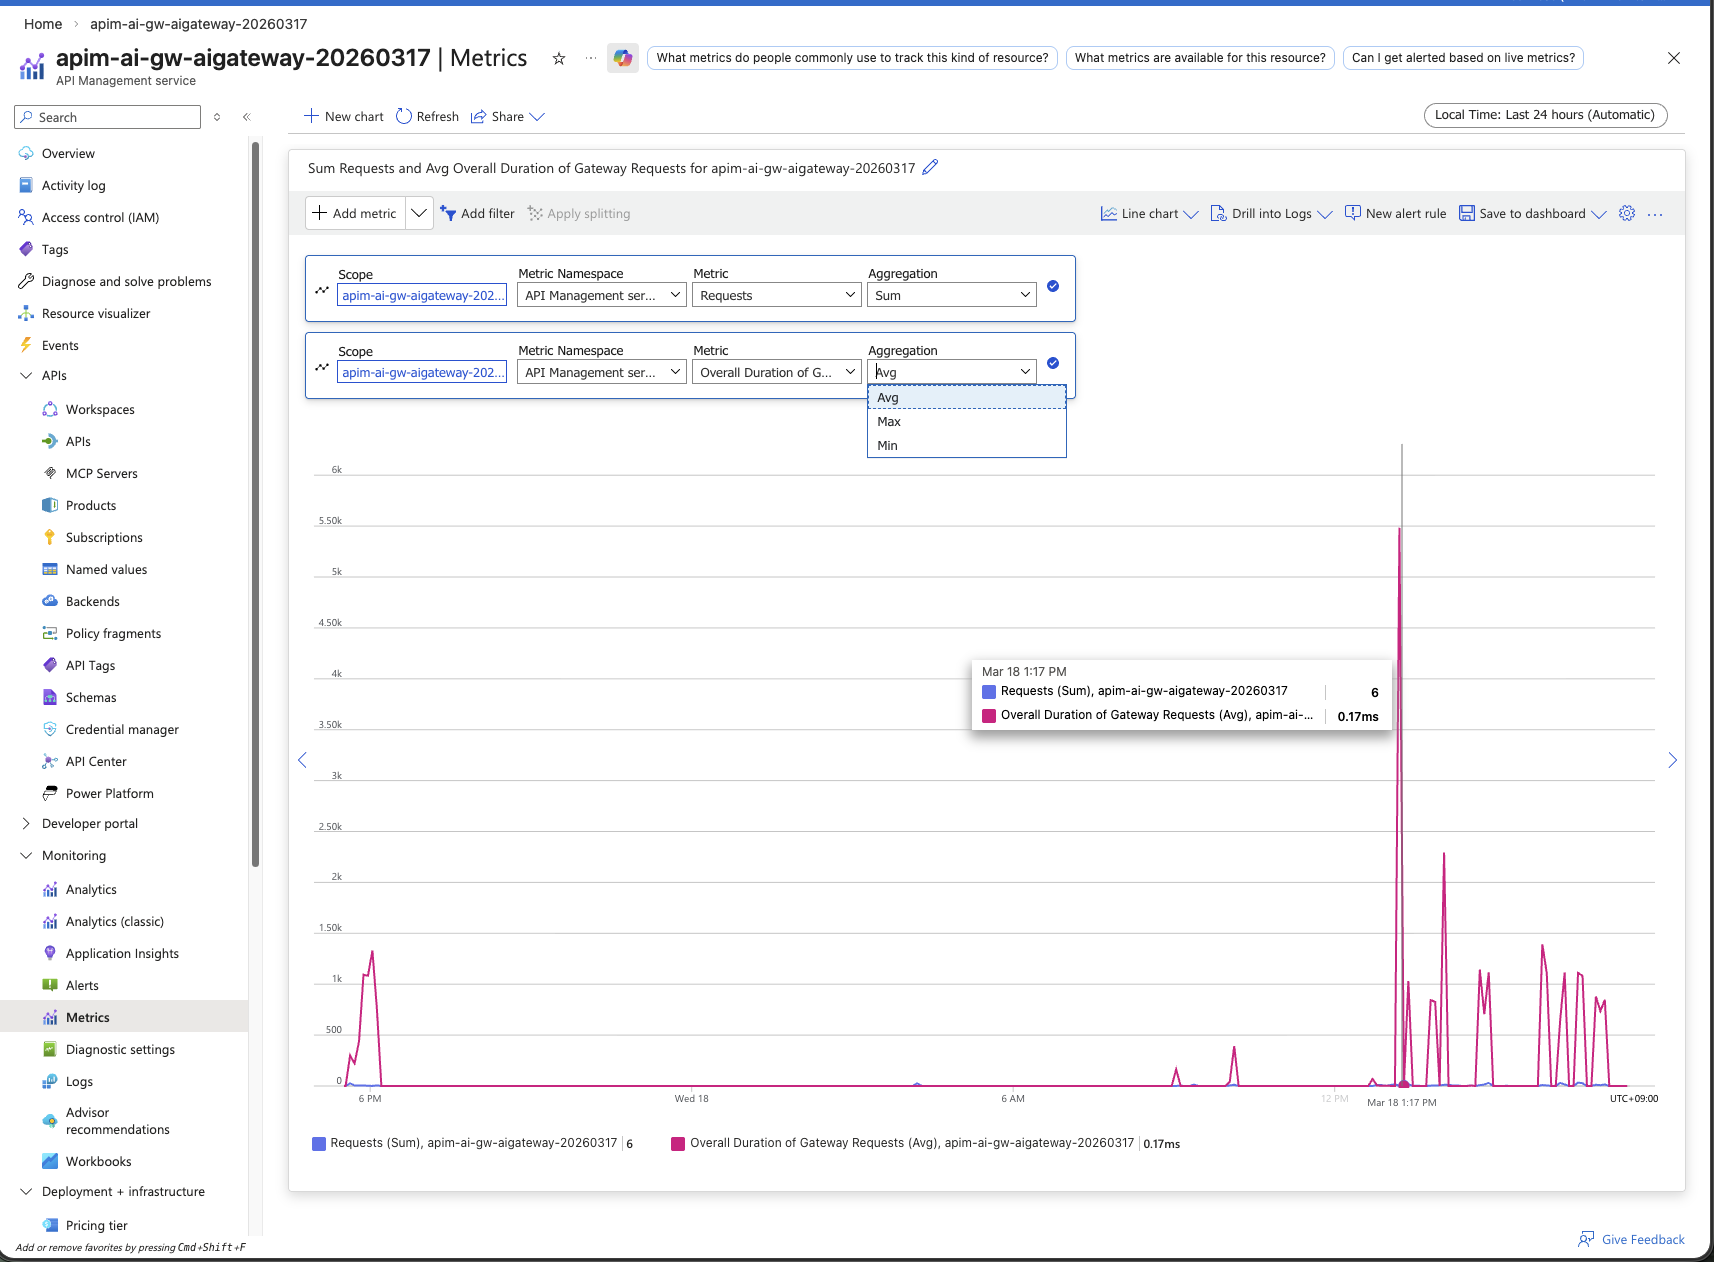

---

### 📊 3-2. Application Insights 응답 시간 분포 (P50/P95/P99)

**경로:** Azure Portal → **Application Insights** → 왼쪽 메뉴 **Performance**

1. **Operations** 탭 → API operation 선택 (예: `POST /openai/deployments/...`)
2. 오른쪽 패널에서 **Overall** 응답 시간 분포 확인 (P50, P95, P99 자동 표시)
3. 시간 범위: **Last 1 hour**

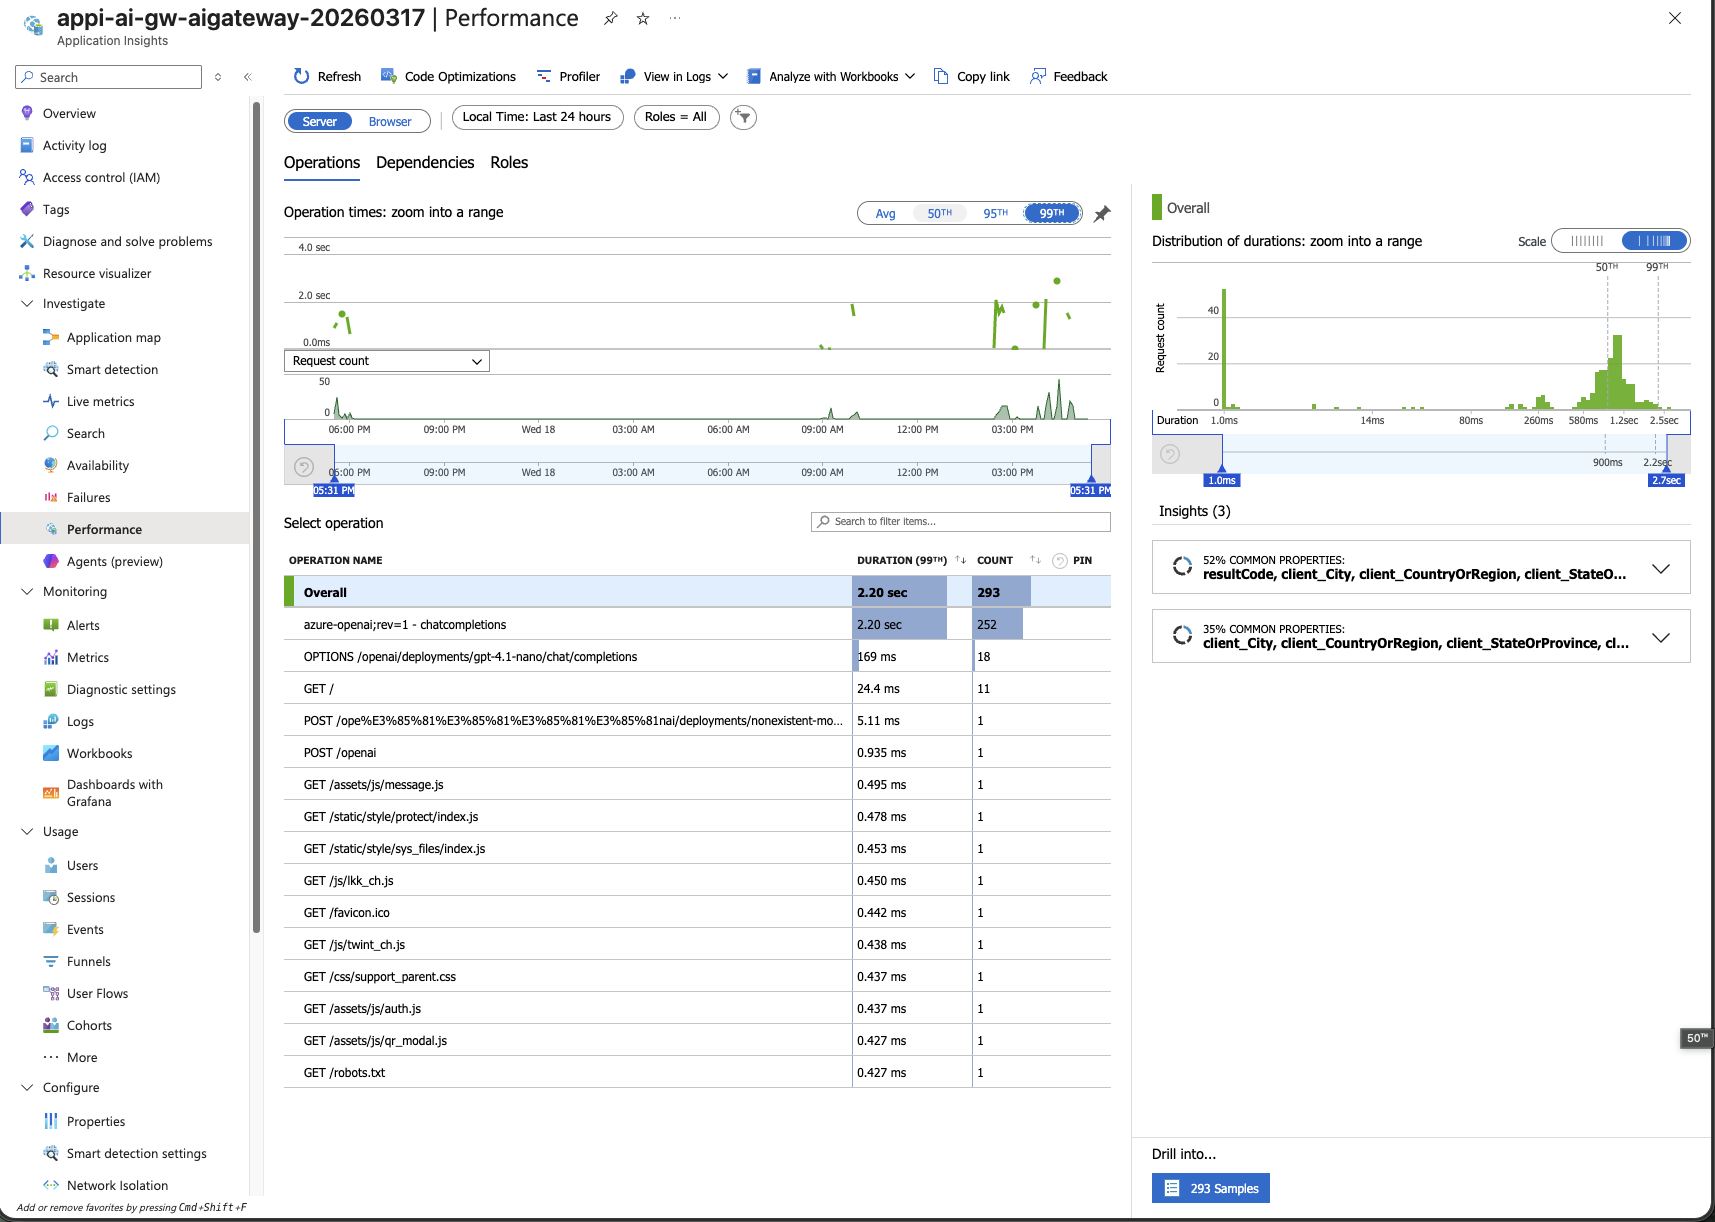

---

### 📊 3-3. 백엔드별 응답 시간 비교

**경로:** Azure Portal → **Application Insights** → 왼쪽 메뉴 **Logs**

```kql
dependencies
| where timestamp > ago(1h)
| extend backend = tostring(target)
| summarize
    calls = count(),
    avgLatency = round(avg(duration), 0),
    p50 = round(percentile(duration, 50), 0),
    p90 = round(percentile(duration, 90), 0),
    p99 = round(percentile(duration, 99), 0),
    minLatency = round(min(duration), 0),
    maxLatency = round(max(duration), 0)
    by backend
| order by avgLatency asc
```

> 📸 캡처 포인트: 백엔드(리전)별 P50/P90/P99 비교 테이블

---

### 📊 3-4. 백엔드별 응답 시간 시계열 차트

**경로:** Azure Portal → **Application Insights** → 왼쪽 메뉴 **Logs**

```kql
dependencies
| where timestamp > ago(1h)
| extend backend = tostring(target)
| summarize avgLatency = avg(duration) by backend, bin(timestamp, 1m)
| render timechart
```

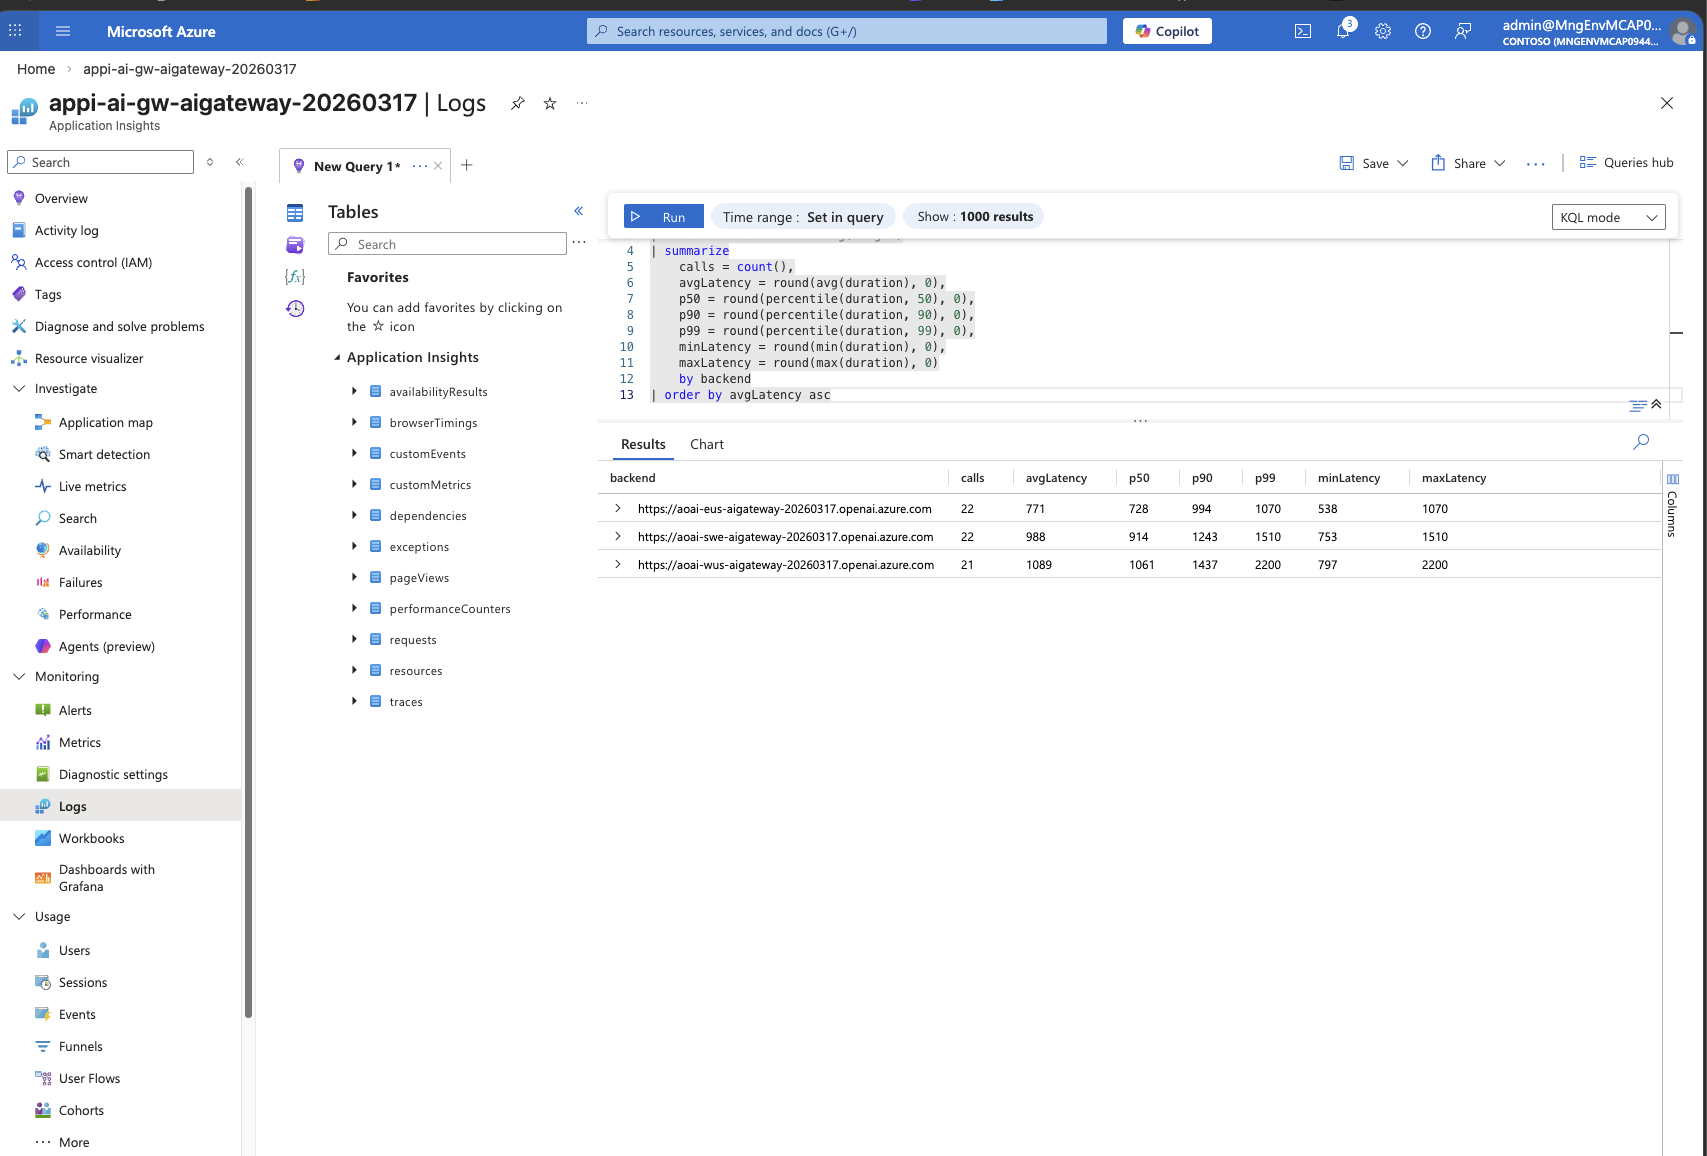
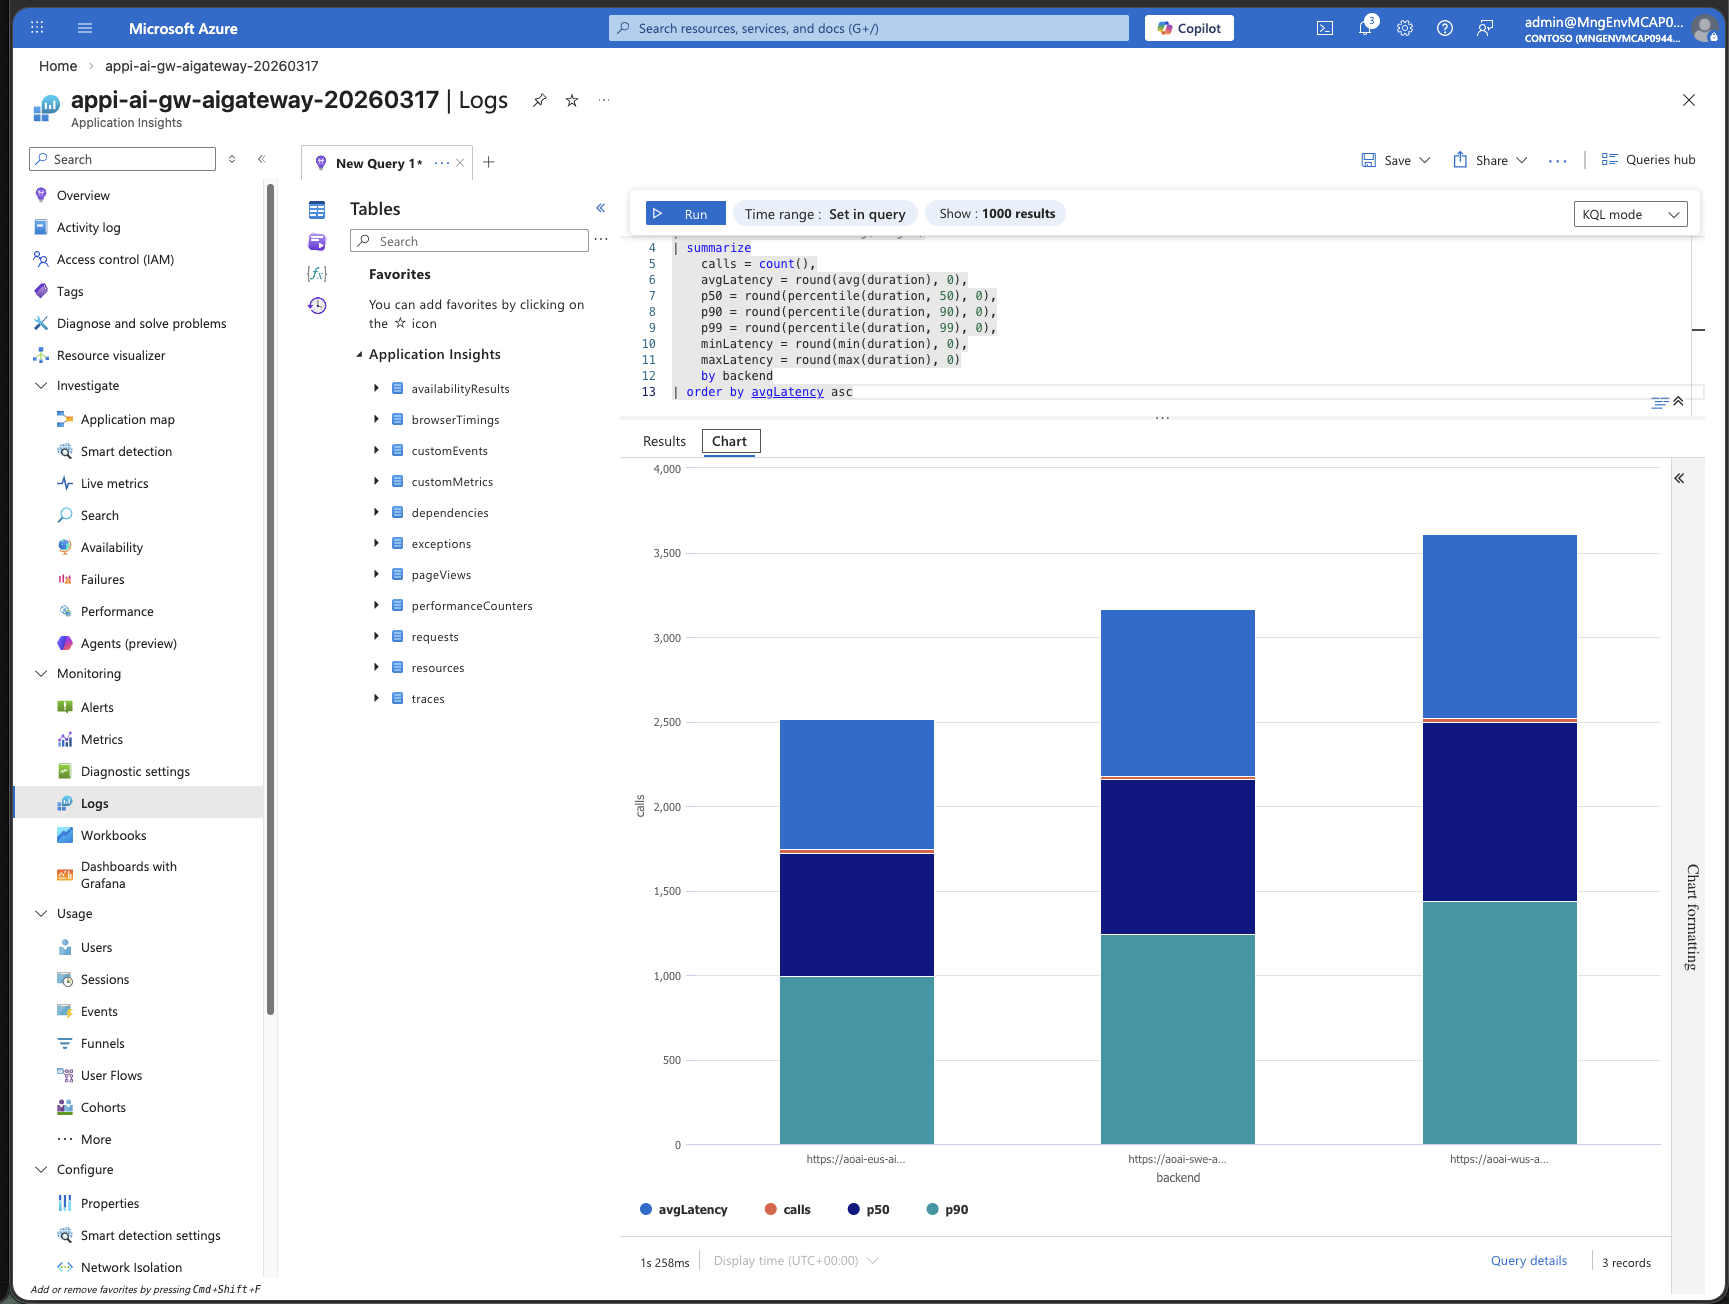

---

### 📊 3-5. 동시 요청 시 성능 변화

**경로:** Azure Portal → **Application Insights** → 왼쪽 메뉴 **Logs**

```kql
requests
| where timestamp > ago(1h)
| summarize 
    requestCount = count(),
    avgDuration = round(avg(duration), 0),
    p95Duration = round(percentile(duration, 95), 0)
    by bin(timestamp, 1m)
| render timechart
```

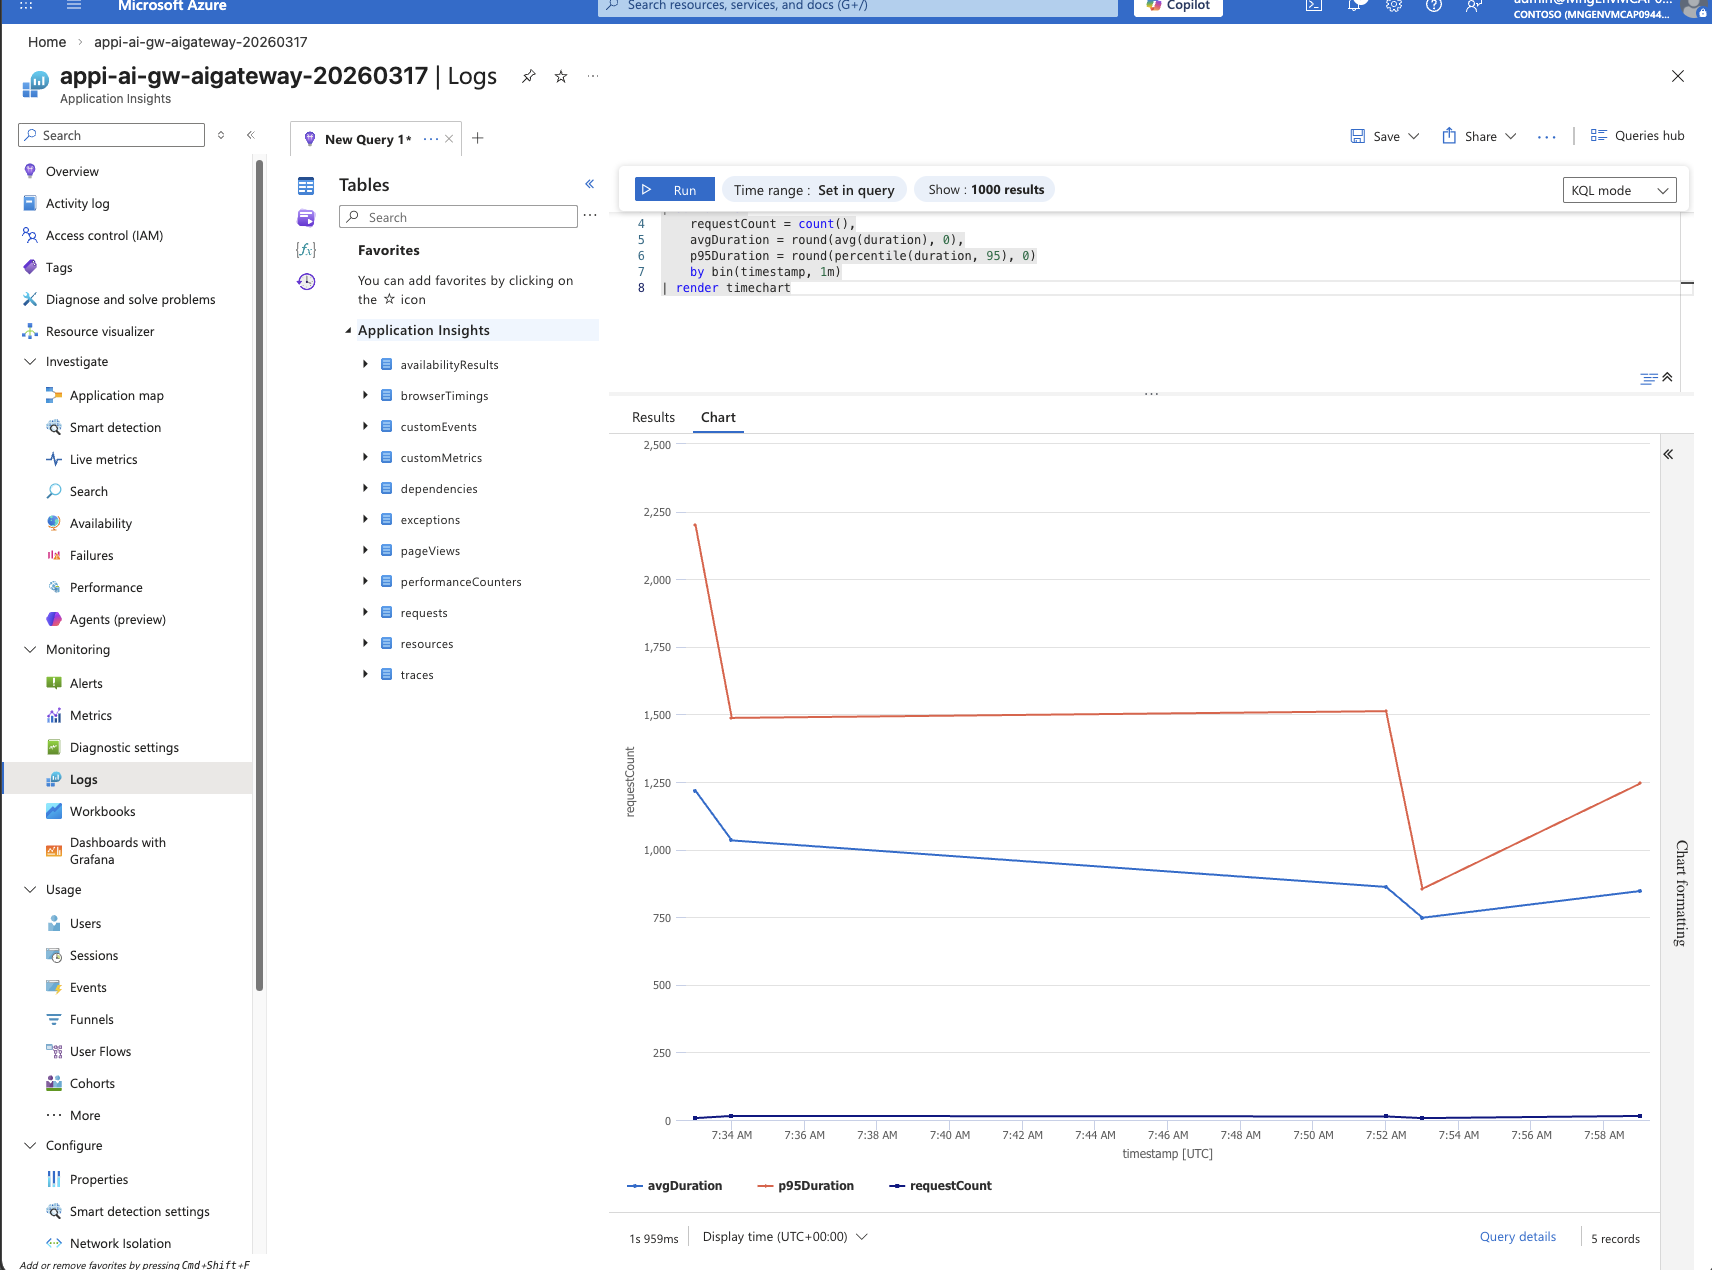

---

### 📊 3-6. APIM Capacity 메트릭 (부하 수준)

**경로:** Azure Portal → **API Management** → 왼쪽 메뉴 **Monitoring** → **Metrics**

1. **Metric**: `Capacity` 선택 → **Aggregation**: Avg
2. 시간 범위: **Last 1 hour**
3. 차트에서 동시 요청 구간의 capacity 변화 확인

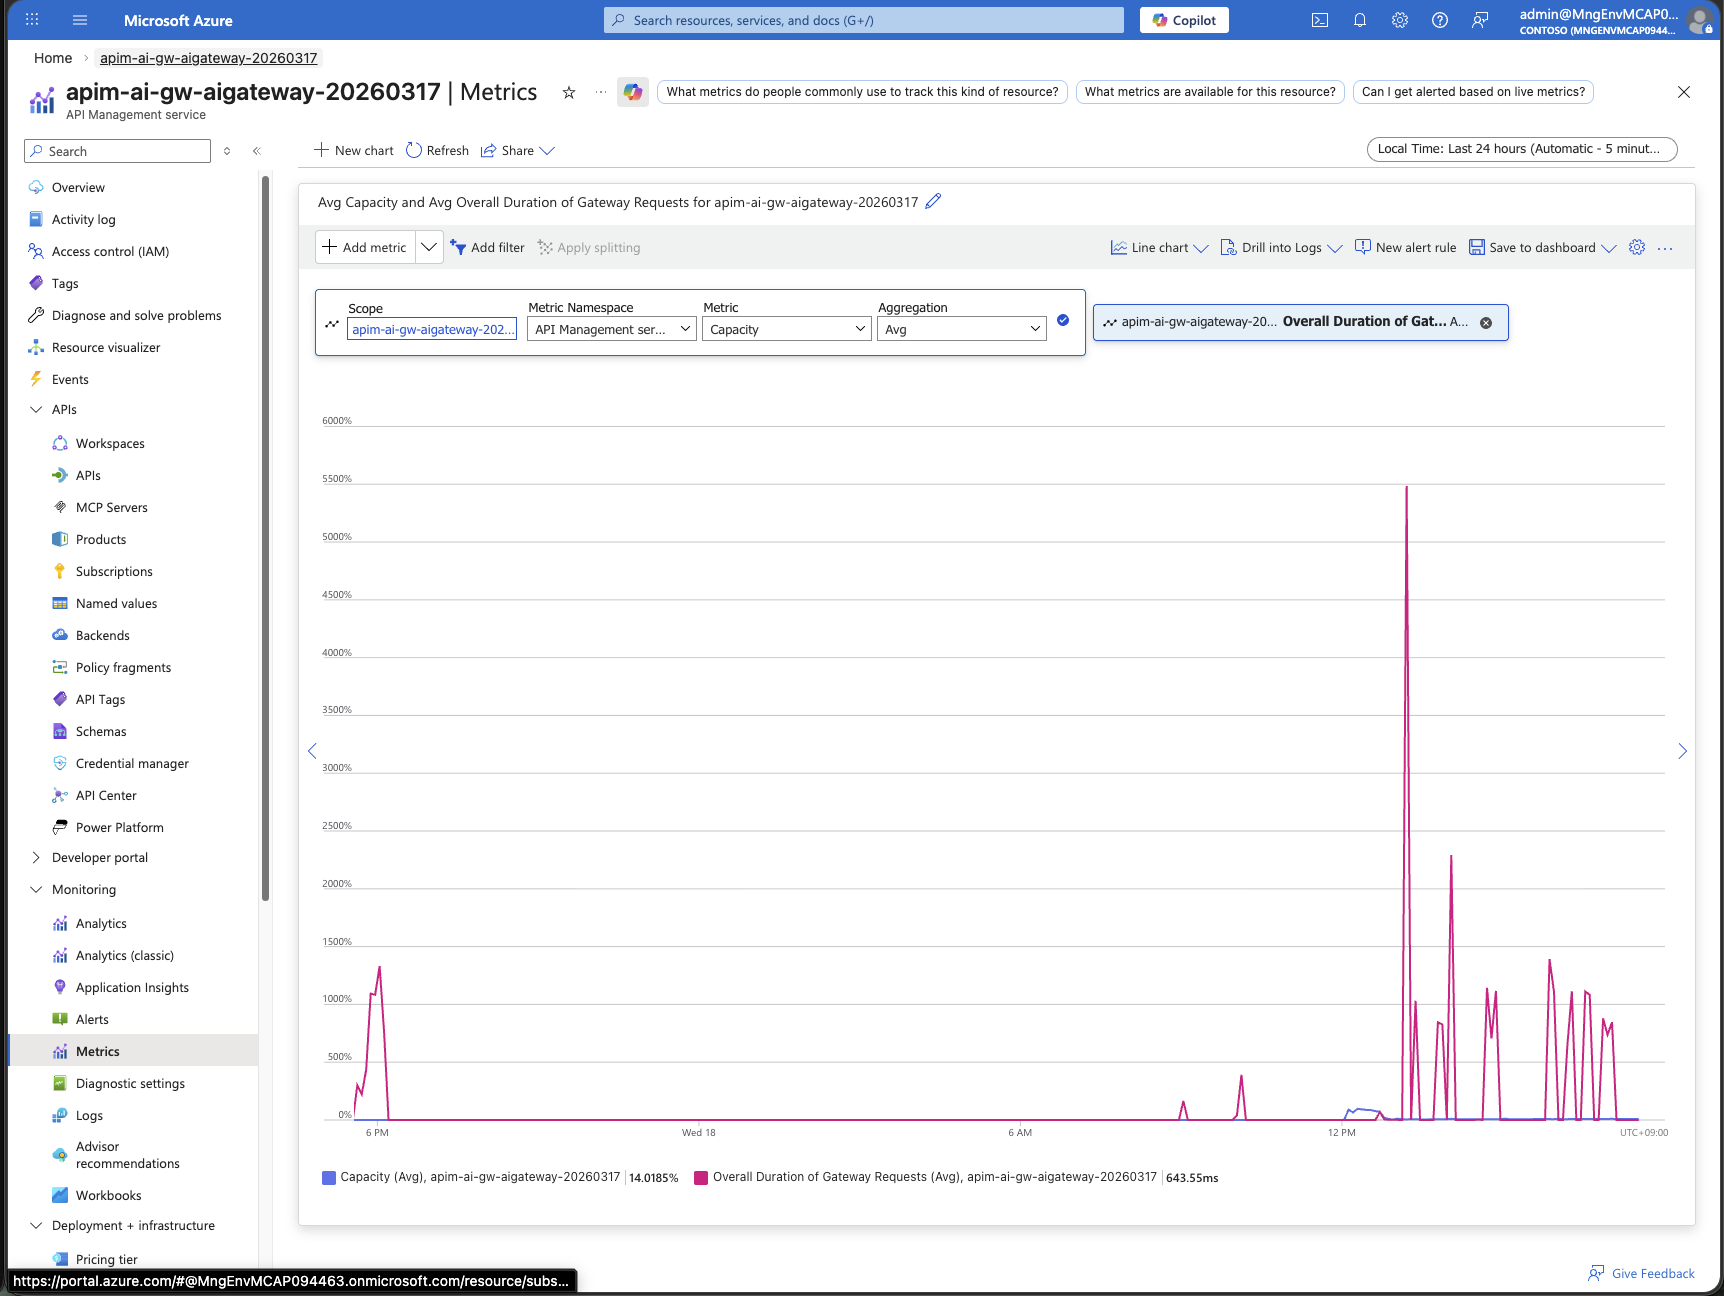

---

### 📊 요약: 캡처 체크리스트

| # | 캡처 대상 | Portal 경로 |
|---|----------|------------|
| 1 | 요청 수 + 평균 응답 시간 | APIM → Metrics → Requests + Duration |
| 2 | P50/P95/P99 응답 시간 분포 | App Insights → Performance |
| 3 | 백엔드별 응답 시간 비교 테이블 | App Insights → Logs → KQL |
| 4 | 백엔드별 응답 시간 시계열 | App Insights → Logs → KQL timechart |
| 5 | 동시 요청 시 성능 변화 | App Insights → Logs → KQL timechart |
| 6 | APIM Capacity (부하 수준) | APIM → Metrics → Capacity |